# 07_AM_MHCII_AT2_VIM_Continuous_Spatial_Association
## Xiaonan Wang
## 18Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"17/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step0 - Read In Files and Set Parameters

In [5]:
x_all = sc.read_h5ad(datadir + "all_updated.h5ad")

In [6]:
AT2 = sc.read_h5ad(outdir + "AT2_updated.h5ad")

In [7]:
x_all, report_AT2 = source.merge_obs_to_main(
    main_adata=x_all,
    subset_adata=AT2,
    columns={
        "AT2_VIMhi_score": "AT2_VIMhi_score",
        "AT2_VIMlo_score": "AT2_VIMlo_score",
        "AT2_VIM_score": "AT2_VIM_score",
        "AT2_VIM_group": "AT2_VIM_group",
    },
    overwrite=True,
    strict_subset=True,
    source_name="AM",
)

In [8]:
import os
if hasattr(os, "sched_getaffinity"):
    print(
        "Available CPUs:",
        len(os.sched_getaffinity(0)),
    )
else:
    print(
        "Available CPUs:",
        os.cpu_count(),
    )

Available CPUs: 17


In [9]:
stage3_common = {
    # Spatial/sample metadata
    "core_col": "core_id",
    "donor_col": "donor_id",
    "tissue_col": "tissue_annotation",
    "tissue": None,

    # Cell annotations
    "celltype_col": "CellType_refined",
    "am_labels": ("AM", "Alveolar Macrophage"),
    "at2_labels": ("AT2",),

    # Spatial coordinates
    "x_col": "x_centroid",
    "y_col": "y_centroid",

    # Continuous cell-state scores
    "mhcii_score_col": "MHCIIhi_score",
    "vim_score_col": "AT2_VIM_score",

    # Within-core AT2-score permutations
    "n_permutations": 999,
}

## Step1 - Balanced extremes

- AM variable: Top vs Bottom; 25% of MHCIIhi_score
- AT2 variable: Mean local AT2_VIM_score  

AM converted into extremes; AT2 remains continuous

In [10]:
stage3_extremes = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_balanced_extremes_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=301,
    verbose=10,

    radii=(25, 50, 100),
    extreme_fraction=0.25,
    min_extreme_cells=5,
    min_at2_neighbors=3,

    **stage3_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    2.7s remaining:    1.3s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    3.1s remaining:    0.8s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    3.7s remaining:    0.4s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    7.6s finished


## Step2 - kNN coninuum

- AM variable: Coninuous MHCIIhi_score
- AT2 variable: Mean AT2_VIM_score among local AT2 cells

Both continuous

In [11]:
stage3_knn = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_knn_continuum_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=302,
    verbose=10,

    k_values=(5, 15, 30),
    neighbor_pool="all",
    min_at2_neighbors=3,
    min_am=10,

    **stage3_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    5.0s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    6.9s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:   10.6s remaining:    5.2s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:   11.6s remaining:    3.2s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:   13.9s remaining:    1.5s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:   17.6s finished


## Step3 - Radius Continuum

- AM variable: Continuous MHCIIhi_score
- AT2 variable: Mean AT2_VIM_score with each radius

Both continuous

In [12]:
stage3_radius = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_radius_continuum_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=303,
    verbose=10,

    radii=(25, 50, 100),
    min_at2_neighbors=3,
    min_am=10,

    **stage3_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    6.9s remaining:    3.4s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    7.5s remaining:    2.1s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    9.9s remaining:    1.1s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:   16.3s finished


## Step4 - Nearest AT2

- AM variable: Continuous MHCIIhi_score
- AT2 varibale: AT2_VIM_score of nearest AT2

Both continuous

In [13]:
stage3_nearest = run_stage3_multicore(
    analysis_function=(
        calculate_stage3_nearest_at2_by_core
    ),
    adata=x_all,
    n_jobs=16,
    random_state=304,
    verbose=10,

    max_distance=100,
    min_am=10,

    **stage3_common,
)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done  47 out of  70 | elapsed:    1.3s remaining:    0.6s
[Parallel(n_jobs=16)]: Done  55 out of  70 | elapsed:    1.3s remaining:    0.4s
[Parallel(n_jobs=16)]: Done  63 out of  70 | elapsed:    1.6s remaining:    0.2s
[Parallel(n_jobs=16)]: Done  70 out of  70 | elapsed:    1.7s finished


## Step5 - Summarise Results and Plotting

In [14]:
stage3_results = pd.concat(
    [
        stage3_extremes,
        stage3_knn,
        stage3_radius,
        stage3_nearest,
    ],
    ignore_index=True,
    sort=False,
)

stage3_results = stage3_results.sort_values(
    [
        "method",
        "scale",
        "tissue_annotation",
        "donor_id",
        "core_id",
    ]
).reset_index(drop=True)

display(stage3_results.head())
display(stage3_results.groupby(["method", "scale"]).size())

,core_id,donor_id,tissue_annotation,method,scale_type,scale,effect,effect_name,n_am_total,n_at2_total,...,null_mean,null_sd,z_score,p_value,n_valid_permutations,fdr_bh,neighbor_pool,coverage_fraction,median_nearest_distance,q90_nearest_distance
0,D1.c1,D1,A,balanced_extremes,radius_um,25.0,0.105402,mean_local_VIM_high_minus_low_MHCII,164,680,...,-0.000830,0.168956,0.628753,0.535,999,0.535,NaN,NaN,NaN,NaN
1,D1.c2,D1,A,balanced_extremes,radius_um,25.0,0.003067,mean_local_VIM_high_minus_low_MHCII,203,961,...,-0.000232,0.139905,0.023575,0.986,999,0.986,NaN,NaN,NaN,NaN
2,D10.c1,D10,A,balanced_extremes,radius_um,25.0,0.080516,mean_local_VIM_high_minus_low_MHCII,1476,510,...,0.003130,0.149135,0.518904,0.591,999,0.771,NaN,NaN,NaN,NaN
3,D10.c2,D10,A,balanced_extremes,radius_um,25.0,-0.017320,mean_local_VIM_high_minus_low_MHCII,815,807,...,0.001151,0.144925,-0.127453,0.902,999,0.902,NaN,NaN,NaN,NaN
4,D2.c1,D2,B,balanced_extremes,radius_um,25.0,0.085048,mean_local_VIM_high_minus_low_MHCII,314,607,...,0.003330,0.123573,0.661294,0.506,999,0.842,NaN,NaN,NaN,NaN


method             scale
balanced_extremes  25.0      7
                   50.0     33
                   100.0    55
knn_continuum      5.0      57
                   15.0     70
                   30.0     70
nearest_at2        100.0    70
radius_continuum   25.0     16
                   50.0     48
                   100.0    63
dtype: int64

In [15]:
stage3_donor_summary, stage3_tissue_tests = (
    summarize_stage3_by_donor_and_tissue(
        stage3_results,
        donor_col="donor_id",
        tissue_col="tissue_annotation",
        core_col="core_id",
        min_donors=3,
    )
)

display(stage3_donor_summary.head())
display(stage3_tissue_tests.head())

,method,scale,scale_type,effect_name,tissue_annotation,donor_id,donor_effect,donor_effect_transformed,n_cores,mean_core_effect,median_core_effect,n_am_analyzed
0,balanced_extremes,25.0,radius_um,mean_local_VIM_high_minus_low_MHCII,A,D1,0.054234,0.054234,2,0.054234,0.054234,24.0
1,balanced_extremes,25.0,radius_um,mean_local_VIM_high_minus_low_MHCII,A,D10,0.031598,0.031598,2,0.031598,0.031598,34.0
2,balanced_extremes,25.0,radius_um,mean_local_VIM_high_minus_low_MHCII,B,D2,0.085048,0.085048,1,0.085048,0.085048,13.0
3,balanced_extremes,25.0,radius_um,mean_local_VIM_high_minus_low_MHCII,V,D11,-0.086010,-0.086010,1,-0.086010,-0.086010,12.0
4,balanced_extremes,25.0,radius_um,mean_local_VIM_high_minus_low_MHCII,V,D2,-0.001914,-0.001914,1,-0.001914,-0.001914,26.0


,method,scale,scale_type,effect_name,tissue_annotation,n_donors,mean_effect,median_effect,ci_low,ci_high,p_value,direction,fdr_bh
0,balanced_extremes,50.0,radius_um,mean_local_VIM_high_minus_low_MHCII,A,13,-0.014167,-0.012158,-0.047291,0.018957,0.414307,negative,0.788891
1,balanced_extremes,50.0,radius_um,mean_local_VIM_high_minus_low_MHCII,V,9,0.025644,0.019488,-0.000207,0.051496,0.054688,positive,0.384521
2,balanced_extremes,100.0,radius_um,mean_local_VIM_high_minus_low_MHCII,A,17,0.000735,-0.001263,-0.017809,0.019280,1.000000,positive,1.000000
3,balanced_extremes,100.0,radius_um,mean_local_VIM_high_minus_low_MHCII,B,7,-0.017277,-0.015007,-0.081626,0.047072,0.296875,negative,0.742188
4,balanced_extremes,100.0,radius_um,mean_local_VIM_high_minus_low_MHCII,V,12,0.022289,0.015977,-0.000818,0.045397,0.092285,positive,0.384521


In [16]:
stage3_results_dict = {
    # Core-level results
    "balanced_extremes": stage3_extremes,
    "knn_continuum": stage3_knn,
    "radius_continuum": stage3_radius,
    "nearest_at2": stage3_nearest,

    # Combined core-level table
    "combined": stage3_results,

    # Donor- and tissue-level results
    "donor_summary": stage3_donor_summary,
    "tissue_tests": stage3_tissue_tests,

    # Analysis settings
    "stage3_common": stage3_common,
}

pd.to_pickle(
    stage3_results_dict,
    "Stage3_all_results.pkl.gz",
    compression="gzip",
)

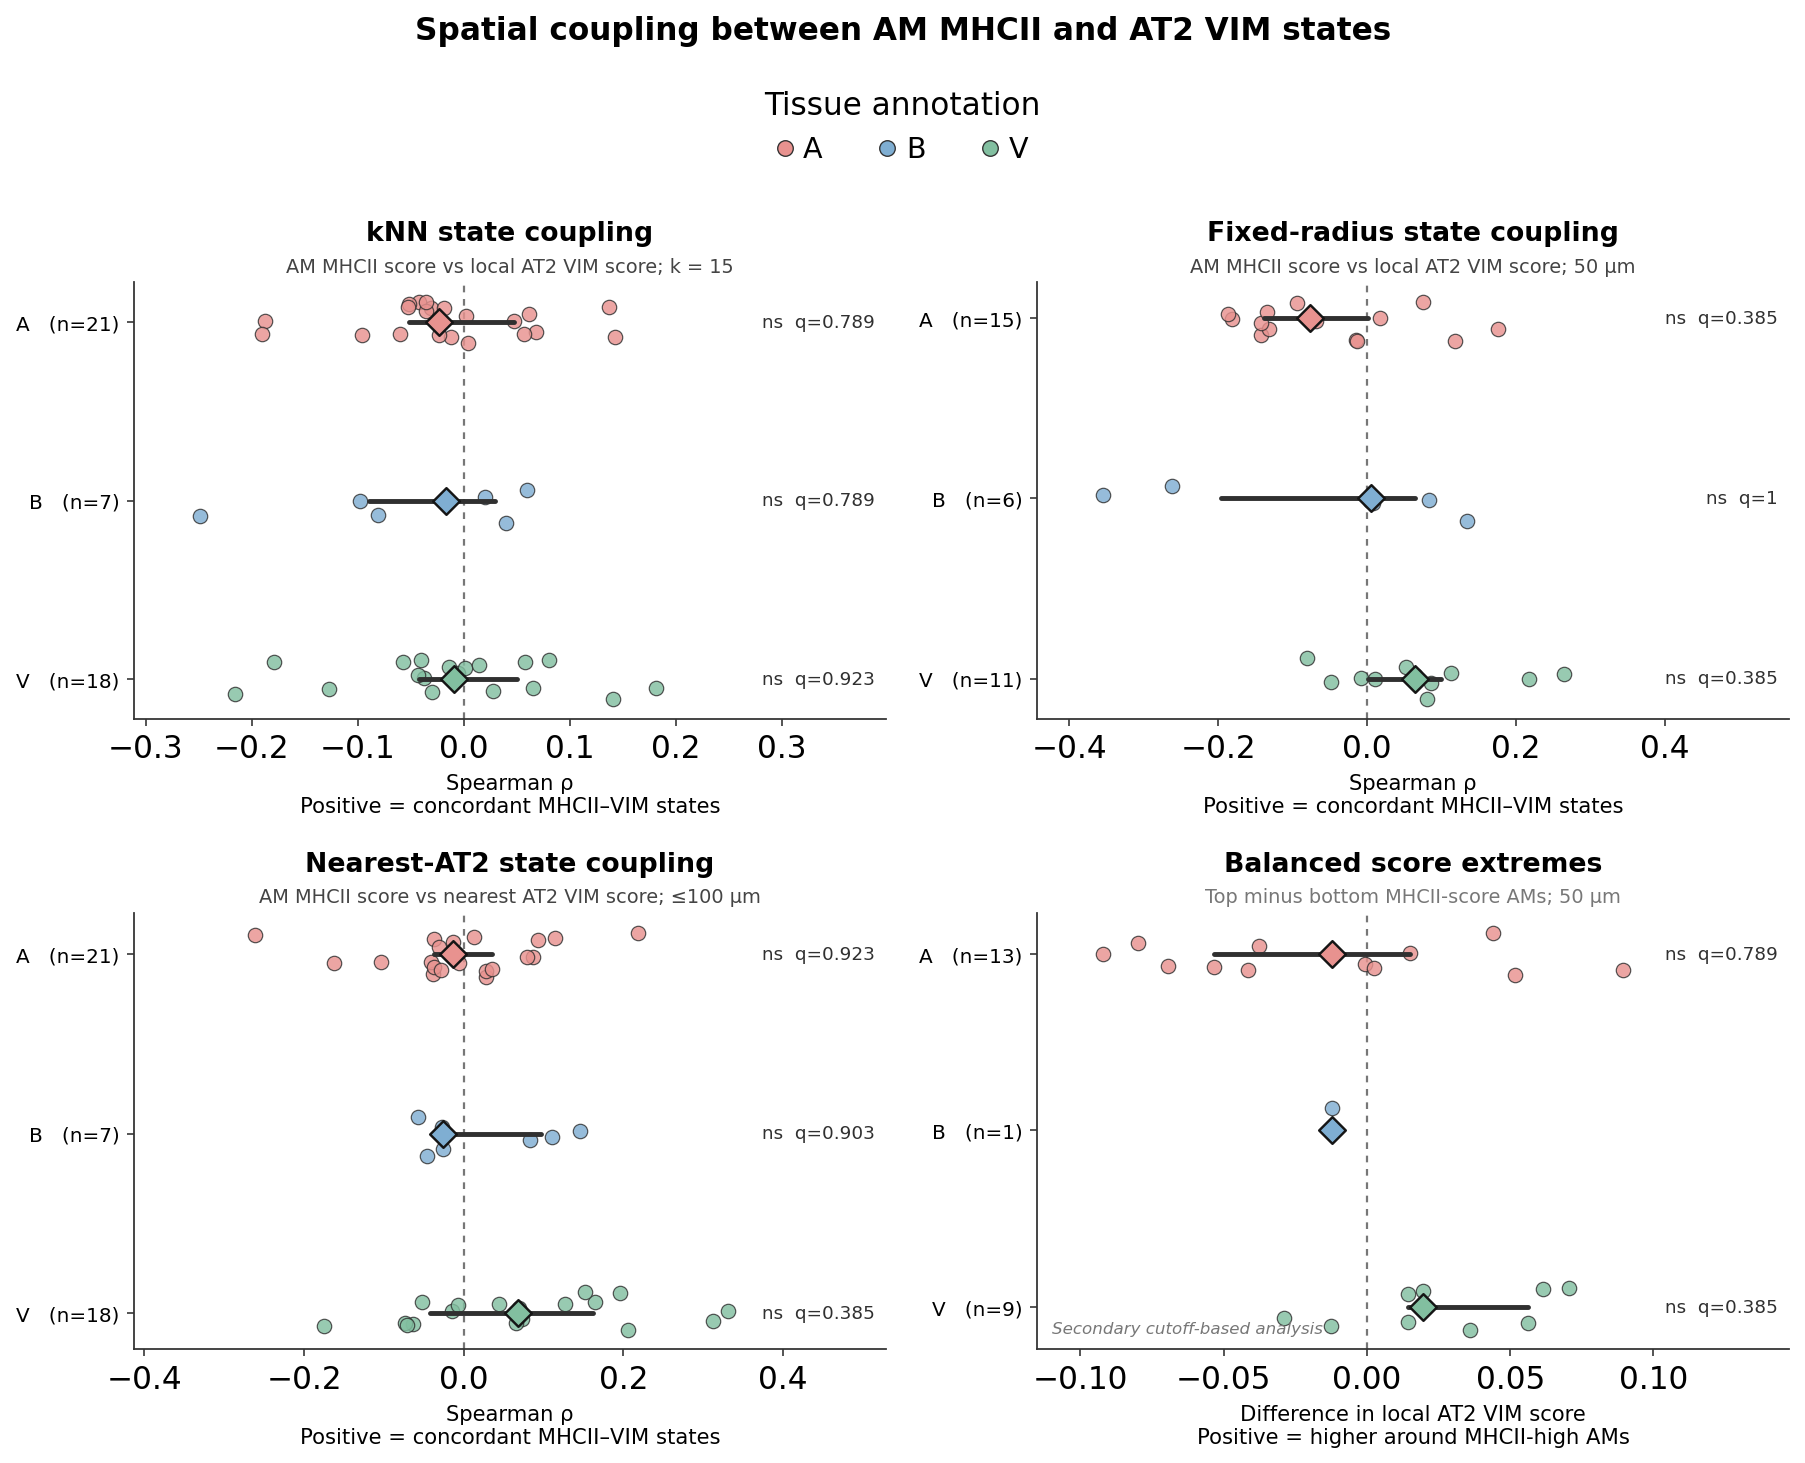

In [21]:
fig, axes, stage3_primary_plot_data = (
    plot_stage3_primary(
        donor_summary=stage3_donor_summary,
        tissue_tests=stage3_tissue_tests,

        tissue_order=("A", "B", "V"),

        tissue_colors={
            "A": "#E8928F",
            "B": "#7FAED2",
            "V": "#82BFA0",
            "None": "#B8B8B8",
        },

        primary_scales={
            "knn_continuum": 15,
            "radius_continuum": 50,
            "nearest_at2": 100,
            "balanced_extremes": 50,
        },

        show_donor_labels=False,
        annotate_fdr=True,
        random_state=123,

        save="Stage3_MHCII_AT2_VIM_primary_results.pdf",
        dpi=300,
    )
)

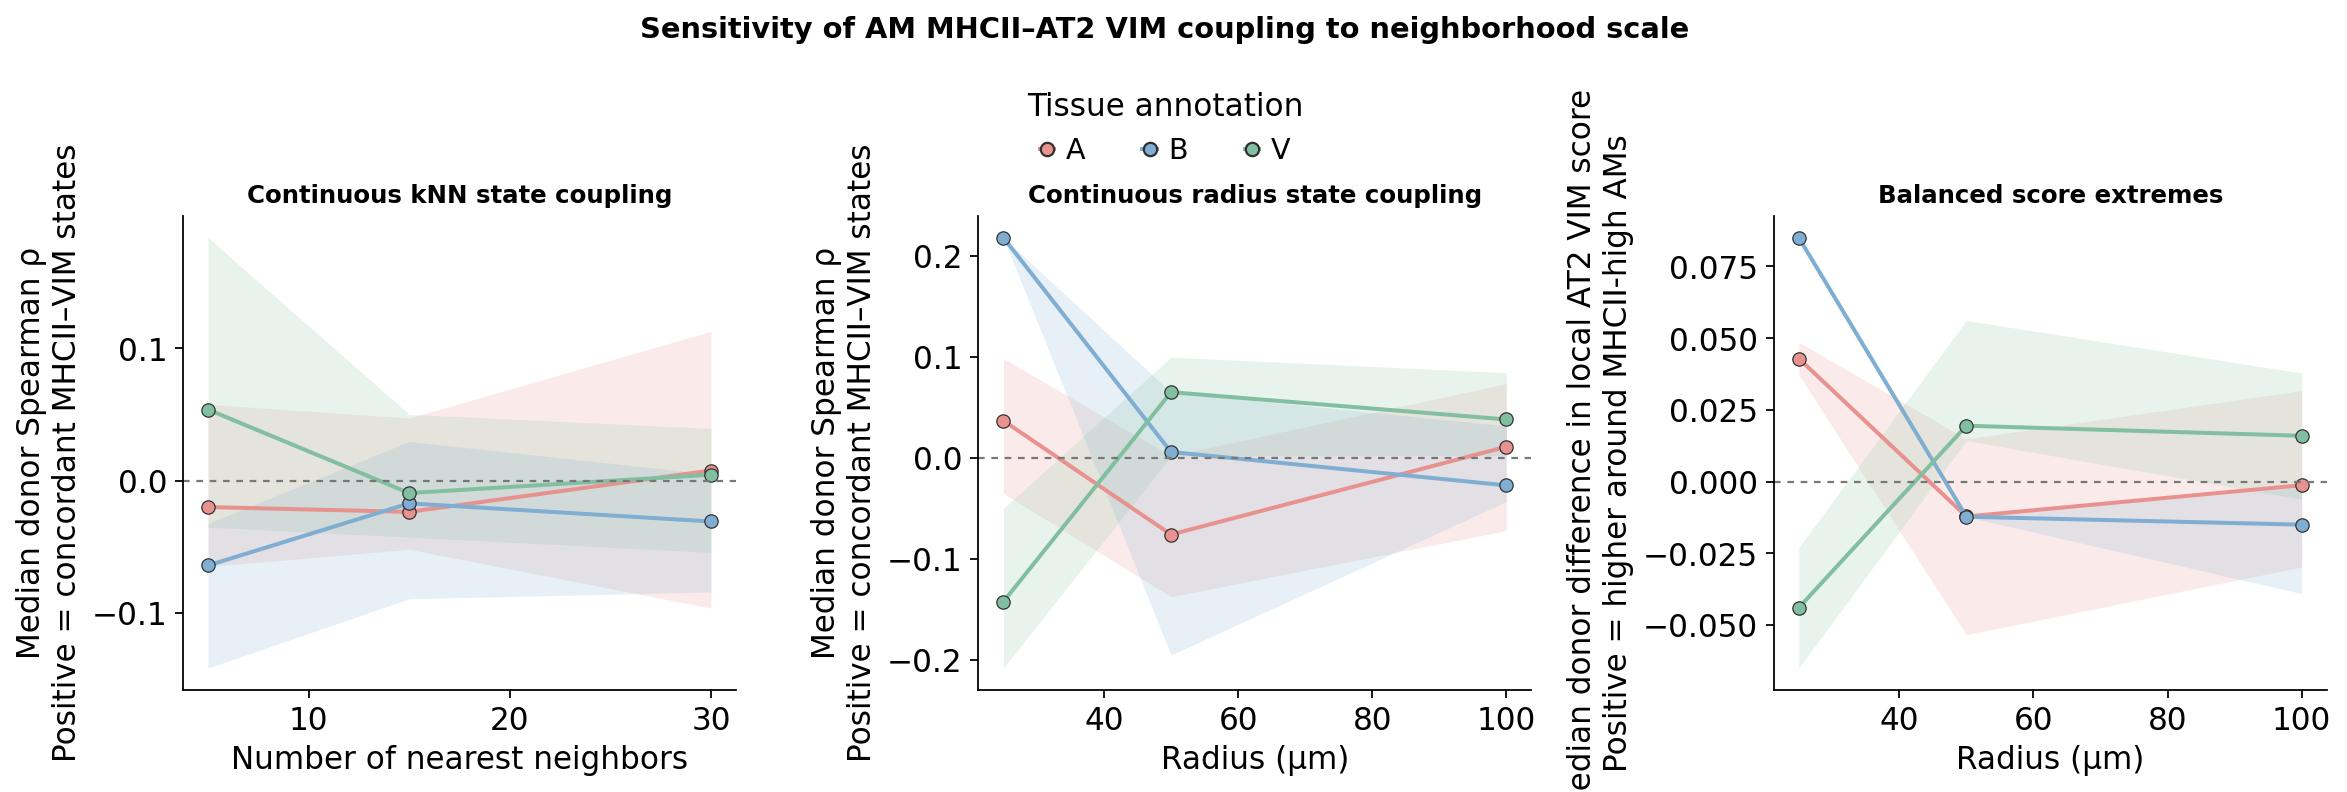

In [18]:
fig, axes, stage3_scale_summary = (
    plot_stage3_scale_sensitivity(
        donor_summary=stage3_donor_summary,

        tissue_order=("A", "B", "V"),

        tissue_colors={
            "A": "#E8928F",
            "B": "#7FAED2",
            "V": "#82BFA0",
            "None": "#B8B8B8",
        },

        methods=(
            "knn_continuum",
            "radius_continuum",
            "balanced_extremes",
        ),

        save="Stage3_MHCII_AT2_VIM_scale_sensitivity.pdf",
        dpi=300,
    )
)